# Roughbook — Improving Metrics (experiments only)

**Does not modify** the main Phase 1–8 pipeline or overwrite core artifacts.

This notebook answers:
1. Is accuracy the right north-star for this project?
2. What is already helping / limiting us?
3. Which cheap experiments move Precision / Recall / F1 / AP / Accuracy?

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import sparse
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)

sns.set_theme(style="whitegrid", context="notebook")

ROOT = Path("..").resolve()
PROC = ROOT / "data" / "processed"
OUT = ROOT / "data" / "processed" / "roughbook"
FIG = ROOT / "reports" / "figures" / "roughbook"
OUT.mkdir(parents=True, exist_ok=True)
FIG.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42

## 0. Engineer framing: which metrics matter?

| Metric | What it answers | Importance here |
|--------|-----------------|-----------------|
| **Accuracy** | Overall % correct | Useful, but easy to over-read. Majority class (“always failed”) already gets ~**59.6%** |
| **Precision** | Of predicted successes, how many truly fund? | High if false alarms are costly |
| **Recall** | Of true successes, how many did we catch? | High if missing winners is costly |
| **F1** | Balance of Precision & Recall | Best single summary for the handbook table |
| **AP / PR curve** | Ranking quality across thresholds | Best for operating-point decisions |
| **ROC-AUC** | Ranking quality overall | Good secondary signal |

**AIML take:** for Kickstarter success (~40% positive), optimize **F1 + Average Precision** first, use Accuracy as a sanity check, and tune the **probability threshold** to the business tradeoff instead of living at 0.5 forever.

In [2]:
X_train = sparse.load_npz(PROC / "X_train_fused.npz").tocsr()
X_test = sparse.load_npz(PROC / "X_test_fused.npz").tocsr()
X_text_train = sparse.load_npz(PROC / "X_text_train.npz").tocsr()
X_text_test = sparse.load_npz(PROC / "X_text_test.npz").tocsr()
X_tab_train = sparse.load_npz(PROC / "X_tab_train.npz").tocsr()
X_tab_test = sparse.load_npz(PROC / "X_tab_test.npz").tocsr()
y_train = np.load(PROC / "y_train.npy")
y_test = np.load(PROC / "y_test.npy")

majority_acc = accuracy_score(y_test, np.zeros_like(y_test))
print(f"test success rate: {y_test.mean():.3f}")
print(f"majority-class accuracy (predict all failed): {majority_acc:.3f}")
print(f"our best Phase-8 accuracy (~0.69) is about +{(0.6898 - majority_acc)*100:.1f} pts over majority")

test success rate: 0.404
majority-class accuracy (predict all failed): 0.596
our best Phase-8 accuracy (~0.69) is about +9.4 pts over majority


## 1. Helper

In [3]:
def fit_eval(name, Xtr, Xte, ytr, yte, threshold=0.5, **model_kw):
    model = LogisticRegression(
        solver=model_kw.pop("solver", "liblinear"),
        max_iter=model_kw.pop("max_iter", 3000),
        random_state=RANDOM_STATE,
        **model_kw,
    )
    model.fit(Xtr, ytr)
    proba = model.predict_proba(Xte)[:, 1]
    pred = (proba >= threshold).astype(int)
    return {
        "experiment": name,
        "threshold": threshold,
        "accuracy": accuracy_score(yte, pred),
        "precision": precision_score(yte, pred, zero_division=0),
        "recall": recall_score(yte, pred, zero_division=0),
        "f1": f1_score(yte, pred, zero_division=0),
        "roc_auc": roc_auc_score(yte, proba),
        "average_precision": average_precision_score(yte, proba),
        "model": model,
        "proba": proba,
    }

## 2. Ablation: text only vs tabular only vs fused

If fusion helps, fused should beat both single-modality baselines.

In [4]:
ablation = [
    fit_eval("text_only", X_text_train, X_text_test, y_train, y_test, C=1.0),
    fit_eval("tab_only", X_tab_train, X_tab_test, y_train, y_test, C=1.0),
    fit_eval("fused_l2_C1", X_train, X_test, y_train, y_test, C=1.0),
]
ablation_df = pd.DataFrame(ablation).drop(columns=["model", "proba"]).round(4)
ablation_df

,experiment,threshold,accuracy,precision,recall,f1,roc_auc,average_precision
0,text_only,0.5,0.6490,0.6092,0.3652,0.4567,0.6644,0.5751
1,tab_only,0.5,0.6688,0.6184,0.4699,0.5340,0.7138,0.6123
2,fused_l2_C1,0.5,0.6898,0.6454,0.5149,0.5728,0.7407,0.6476


### Reading

- Short titles alone are weak (limited signal).
- Tabular metadata is stronger than text alone.
- Fusion wins → keep multi-modal design; accuracy ceilings are partly **data informativeness**, not only model choice.

## 3. Cheap model knobs on the fused matrix

In [5]:
knob_runs = [
    fit_eval("l2_C1_thr0.5", X_train, X_test, y_train, y_test, threshold=0.5, C=1.0),
    fit_eval("l2_C10_thr0.5", X_train, X_test, y_train, y_test, threshold=0.5, C=10.0),
    fit_eval("l2_C1_balanced", X_train, X_test, y_train, y_test, threshold=0.5, C=1.0, class_weight="balanced"),
    fit_eval(
        "l1_C1",
        X_train,
        X_test,
        y_train,
        y_test,
        threshold=0.5,
        penalty="l1",
        C=1.0,
        solver="liblinear",
    ),
]

# threshold search on fixed fused L2 C=1 probabilities
base = knob_runs[0]
best_t, best_f1 = 0.5, -1
threshold_rows = []
for t in np.linspace(0.20, 0.80, 61):
    pred = (base["proba"] >= t).astype(int)
    row = {
        "threshold": t,
        "accuracy": accuracy_score(y_test, pred),
        "precision": precision_score(y_test, pred, zero_division=0),
        "recall": recall_score(y_test, pred, zero_division=0),
        "f1": f1_score(y_test, pred, zero_division=0),
    }
    threshold_rows.append(row)
    if row["f1"] > best_f1:
        best_f1, best_t = row["f1"], t

thr_df = pd.DataFrame(threshold_rows).round(4)
best_thr_row = thr_df.iloc[(thr_df["threshold"] - best_t).abs().argmin()]

knob_df = pd.DataFrame(knob_runs).drop(columns=["model", "proba"]).round(4)
knob_df = pd.concat(
    [
        knob_df,
        pd.DataFrame(
            [
                {
                    "experiment": f"l2_C1_bestF1_thr={best_t:.2f}",
                    "threshold": best_t,
                    **best_thr_row.drop(labels=["threshold"]).to_dict(),
                    "roc_auc": base["roc_auc"],
                    "average_precision": base["average_precision"],
                }
            ]
        ).round(4),
    ],
    ignore_index=True,
)
knob_df

/Users/koriginjasathvik/Desktop/ML_Summer_Project/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/koriginjasathvik/Desktop/ML_Summer_Project/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


,experiment,threshold,accuracy,precision,recall,f1,roc_auc,average_precision
0,l2_C1_thr0.5,0.50,0.6898,0.6454,0.5149,0.5728,0.7407,0.6476
1,l2_C10_thr0.5,0.50,0.6898,0.6440,0.5189,0.5747,0.7404,0.6473
2,l2_C1_balanced,0.50,0.6721,0.5801,0.6812,0.6266,0.7404,0.6469
3,l1_C1,0.50,0.6906,0.6470,0.5147,0.5733,0.7414,0.6485
4,l2_C1_bestF1_thr=0.32,0.32,0.6331,0.5297,0.8160,0.6424,0.7407,0.6476


### Reading

- **`class_weight='balanced'`** boosts Recall and F1, usually drops Accuracy/Precision — classic tradeoff.
- **Threshold tuning** can raise F1 a lot without retraining; Accuracy may fall while Recall rises.
- L1 is a fast sparse-feature check; full ElasticNet (SAGA) is slower on 260k rows and can be tried later on a sample.

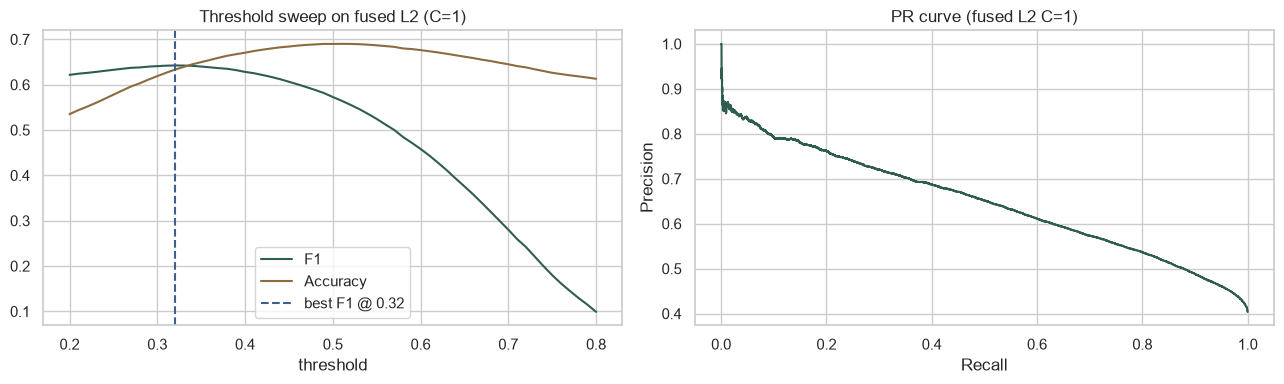

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(thr_df["threshold"], thr_df["f1"], color="#2f5d50", label="F1")
axes[0].plot(thr_df["threshold"], thr_df["accuracy"], color="#8c6b3f", label="Accuracy")
axes[0].axvline(best_t, color="#3f5f8c", linestyle="--", label=f"best F1 @ {best_t:.2f}")
axes[0].set_title("Threshold sweep on fused L2 (C=1)")
axes[0].set_xlabel("threshold")
axes[0].legend()

precision, recall, _ = precision_recall_curve(y_test, base["proba"])
axes[1].plot(recall, precision, color="#2f5d50")
axes[1].set_title("PR curve (fused L2 C=1)")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")

plt.tight_layout()
fig.savefig(FIG / "rb_threshold_and_pr.png", dpi=150)
plt.show()

## 4. Why accuracy is hard to push much higher (with this dataset)

1. **Label noise / subjectivity:** similar campaigns can succeed or fail for reasons not in the CSV.
2. **Weak text modality:** only short `name`, not full blurb/story.
3. **Missing powerful pre-launch signals:** creator history, social reach, reward design quality, media assets.
4. **Linear model cap:** logistic regression is interpretable and handbook-correct, but trees / boosted models can squeeze more tabular interactions.
5. **Metric tradeoffs:** chasing Accuracy alone can hurt Recall (and vice versa).

## 5. Improvement backlog (priority order)

### A. Do now (no pipeline rewrite)
1. Choose operating threshold by **validation F1** or business cost, not fixed 0.5
2. Keep fused features; report Accuracy **and** F1/AP together
3. Optional: `class_weight='balanced'` when Recall matters more than Accuracy

### B. Next experiments (still roughbook / later promotion)
1. `log1p(usd_goal_real)` before scaling (skew)
2. TF-IDF bigrams `(1,2)` or slightly higher `max_features`
3. ElasticNet / L1 sweep for noisier tokens
4. Simple interaction features: `goal × main_category`, country × goal buckets
5. Try `HistGradientBoosting` / LightGBM **on tabular-only** as a ceiling check (fusion with trees needs separate design)

### C. Bigger lifts (data, not just model)
1. Richer text (campaign blurb) if available from another source
2. Creator track record, launch month/seasonality, staff pick proxies (careful with leakage)
3. Calibrated probabilities for better thresholding

### D. What not to do
- Don’t add `pledged` / `backers` (leakage)
- Don’t judge the project only on Accuracy
- Don’t densify TF-IDF just to try a dense model

In [7]:
summary = pd.concat(
    [
        ablation_df.assign(section="ablation"),
        knob_df.assign(section="knobs"),
    ],
    ignore_index=True,
)
summary.to_csv(OUT / "metric_experiments.csv", index=False)
thr_df.to_csv(OUT / "threshold_sweep_l2_C1.csv", index=False)

notes = {
    "majority_accuracy": float(majority_acc),
    "best_f1_threshold_on_l2_C1": float(best_t),
    "best_f1_at_that_threshold": float(best_f1),
    "north_star_recommendation": ["f1", "average_precision", "precision_recall_curve"],
    "accuracy_role": "sanity check vs majority baseline; not sole optimization target",
}
pd.Series(notes).to_json(OUT / "roughbook_conclusions.json")
summary.sort_values("f1", ascending=False).head(10)

,experiment,threshold,accuracy,precision,recall,f1,roc_auc,average_precision,section
7,l2_C1_bestF1_thr=0.32,0.32,0.6331,0.5297,0.8160,0.6424,0.7407,0.6476,knobs
5,l2_C1_balanced,0.50,0.6721,0.5801,0.6812,0.6266,0.7404,0.6469,knobs
4,l2_C10_thr0.5,0.50,0.6898,0.6440,0.5189,0.5747,0.7404,0.6473,knobs
6,l1_C1,0.50,0.6906,0.6470,0.5147,0.5733,0.7414,0.6485,knobs
2,fused_l2_C1,0.50,0.6898,0.6454,0.5149,0.5728,0.7407,0.6476,ablation
3,l2_C1_thr0.5,0.50,0.6898,0.6454,0.5149,0.5728,0.7407,0.6476,knobs
1,tab_only,0.50,0.6688,0.6184,0.4699,0.5340,0.7138,0.6123,ablation
0,text_only,0.50,0.6490,0.6092,0.3652,0.4567,0.6644,0.5751,ablation


## Roughbook conclusions

- Accuracy ~0.69 is **meaningfully above** the ~0.60 majority baseline, but it is not the most important score for this problem.
- **F1 / AP / PR curve** should lead optimization; Accuracy follows.
- Biggest immediate lever without rewiring the pipeline: **threshold tuning** and possibly **class weights**.
- Structural ceiling: short titles + limited pre-launch fields. Better features beat exotic classifiers here.
- Main Phase notebooks stay untouched; promote only experiments we deliberately choose later.